# US Museums Dataset — Full Analysis Report

**Source:** Institute of Museum and Library Services (IMLS) Museum Universe Data File, 33,072 records covering all known museums in the United States.

## Executive Summary

This report works through eight questions about US museums. The headline findings:

- The dataset contains **33,072 museums** across all 50 states, DC, and US territories. About 71% are classified as either Historic Preservation sites or General Museums.
- **California** has the most museums in absolute terms (2,670). On a per-capita basis **Vermont** leads (45.4 museums per 100,000 residents); **Utah** has the fewest per capita (5.2).
- The dataset includes **258 zoos** and **100 aquariums**, plus another ~200 wildlife preserves and sanctuaries that share the same IMLS category code.
- **Art museums** have far higher median revenue (~$5.7M) than any other type — five times the next category. **Historic preservation sites** have the lowest (~$81K).
- Revenue is distributed approximately log-normally, spanning nine orders of magnitude. The high tail is dominated by parent universities filing Form 990s on behalf of museums they own — a recurring data-quality issue addressed throughout this report.

Run **Kernel → Restart Kernel and Run All Cells** to reproduce. Self-contained; needs only `museums.csv` in the same folder.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Currency formatter used by several charts
def money(x, pos=None):
    if x == 0: return "$0"
    a = abs(x)
    if a >= 1e9: return f"${x/1e9:.0f}B"
    if a >= 1e6: return f"${x/1e6:.0f}M"
    if a >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"
money_fmt = FuncFormatter(money)

df = pd.read_csv("museums.csv", low_memory=False)
print(f"Loaded {len(df):,} museums")

Loaded 33,072 museums


---
## Question 1: What's in the dataset?

Before any analysis, we need to understand what fields the dataset contains and what state they're in.

In [2]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:")
for c in df.columns:
    print(f"  {c}")

Shape: 33,072 rows × 25 columns

Columns:
  Museum ID
  Museum Name
  Legal Name
  Alternate Name
  Museum Type
  Institution Name
  Street Address (Administrative Location)
  City (Administrative Location)
  State (Administrative Location)
  Zip Code (Administrative Location)
  Street Address (Physical Location)
  City (Physical Location)
  State (Physical Location)
  Zip Code (Physical Location)
  Phone Number
  Latitude
  Longitude
  Locale Code (NCES)
  County Code (FIPS)
  State Code (FIPS)
  Region Code (AAM)
  Employer ID Number
  Tax Period
  Income
  Revenue


In [3]:
df.head(3)

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0


### What this tells us

The dataset has 25 columns covering three broad areas: **identification** (museum and legal names, IDs), **location** (street, city, state, ZIP, lat/lon, both administrative and physical addresses), and **finances** (revenue, income, tax period, EIN). Each row is one museum, indexed by Museum ID.

The dataset is from IMLS, a US government agency, and the financial fields come from IRS Form 990 filings. This means we have institutional financials for any museum that's a registered nonprofit and files annually — but not for museums that are part of universities (which file under their parent), are too small to file (under the 990-N threshold), or are operated by government agencies.

---
## Question 2: Cleaning and preparing the dataset

Three issues need fixing before analysis:

1. The Physical Location columns are 72% missing. The Administrative Location columns are complete and contain the same information for nearly all museums, so we'll work from those.
2. Revenue and Income contain ~32% sentinel zeros. A literal $0 of revenue is implausible for an operating museum — these are records where the museum either didn't file or filed a 990-N postcard that omits dollar amounts. We convert them to NaN so they don't drag down averages.
3. Text columns are stored in ALL CAPS. We Title-Case them for readability.
4. The dataset has no population data — we'll merge in 2020 Census state populations to support per-capita analysis later.

In [4]:
# 1. Use admin location and rename for convenience
df = df.rename(columns={
    "City (Administrative Location)":  "city",
    "State (Administrative Location)": "state",
    "Museum Type":                     "museum_type",
})
df["city"] = df["city"].str.title()
df["museum_type"] = df["museum_type"].str.title()

# 2. Convert sentinel-zero revenue/income to NaN
for col in ["Revenue", "Income"]:
    df[col] = df[col].where(df[col] != 0, np.nan)

# 3. Add 2020 Census state populations
state_pop = {
    "AL": 5024279, "AK": 733391, "AZ": 7151502, "AR": 3011524,
    "CA": 39538223, "CO": 5773714, "CT": 3605944, "DE": 989948,
    "DC": 689545, "FL": 21538187, "GA": 10711908, "HI": 1455271,
    "ID": 1839106, "IL": 12812508, "IN": 6785528, "IA": 3190369,
    "KS": 2937880, "KY": 4505836, "LA": 4657757, "ME": 1362359,
    "MD": 6177224, "MA": 7029917, "MI": 10077331, "MN": 5706494,
    "MS": 2961279, "MO": 6154913, "MT": 1084225, "NE": 1961504,
    "NV": 3104614, "NH": 1377529, "NJ": 9288994, "NM": 2117522,
    "NY": 20201249, "NC": 10439388, "ND": 779094, "OH": 11799448,
    "OK": 3959353, "OR": 4237256, "PA": 13002700, "RI": 1097379,
    "SC": 5118425, "SD": 886667, "TN": 6910840, "TX": 29145505,
    "UT": 3271616, "VT": 643077, "VA": 8631393, "WA": 7705281,
    "WV": 1793716, "WI": 5893718, "WY": 576851,
}
df["state_population"] = df["state"].map(state_pop)

print(f"Usable revenue values: {df['Revenue'].notna().sum():,}")
print(f"Usable income values : {df['Income'].notna().sum():,}")
print(f"States with population: {df['state_population'].notna().sum():,}")

Usable revenue values: 11,507
Usable income values : 12,221
States with population: 33,072


### What this tells us

After cleaning, about 11,500 museums (35%) have usable revenue figures — the rest didn't file a 990 with dollar amounts. That's a meaningful constraint: any financial analysis represents a third of the dataset, biased toward larger institutions that file full returns. Smaller museums are underrepresented in financial analysis even though they dominate the overall count.

Population data is available for all 50 states plus DC. The five US territories that appear in the dataset (PR, VI, GU, AS, MP) have small museum counts and aren't a focus of this analysis.

---
## Question 3: Which states have the most museums per capita?

Counting museums by state is misleading — California has the most museums (2,670) simply because it has the most people. Per-capita comparison reveals which states actually concentrate museums relative to population.

In [5]:
states = (df.groupby("state")
            .agg(museums=("Museum ID", "size"),
                 population=("state_population", "first"))
            .dropna(subset=["population"]))
states["per_100k"] = (states["museums"] / states["population"] * 100_000).round(2)
states = states.sort_values("per_100k", ascending=False)

print("Top 5:")
print(states.head().to_string())
print("\nBottom 5:")
print(states.tail().sort_values("per_100k").to_string())

Top 5:
       museums  population  per_100k
state                               
VT         292      643077     45.41
ME         521     1362359     38.24
ND         269      779094     34.53
WY         192      576851     33.28
DC         190      689545     27.55

Bottom 5:
       museums  population  per_100k
state                               
UT         170     3271616      5.20
FL        1149    21538187      5.33
NV         174     3104614      5.60
GA         668    10711908      6.24
AZ         449     7151502      6.28


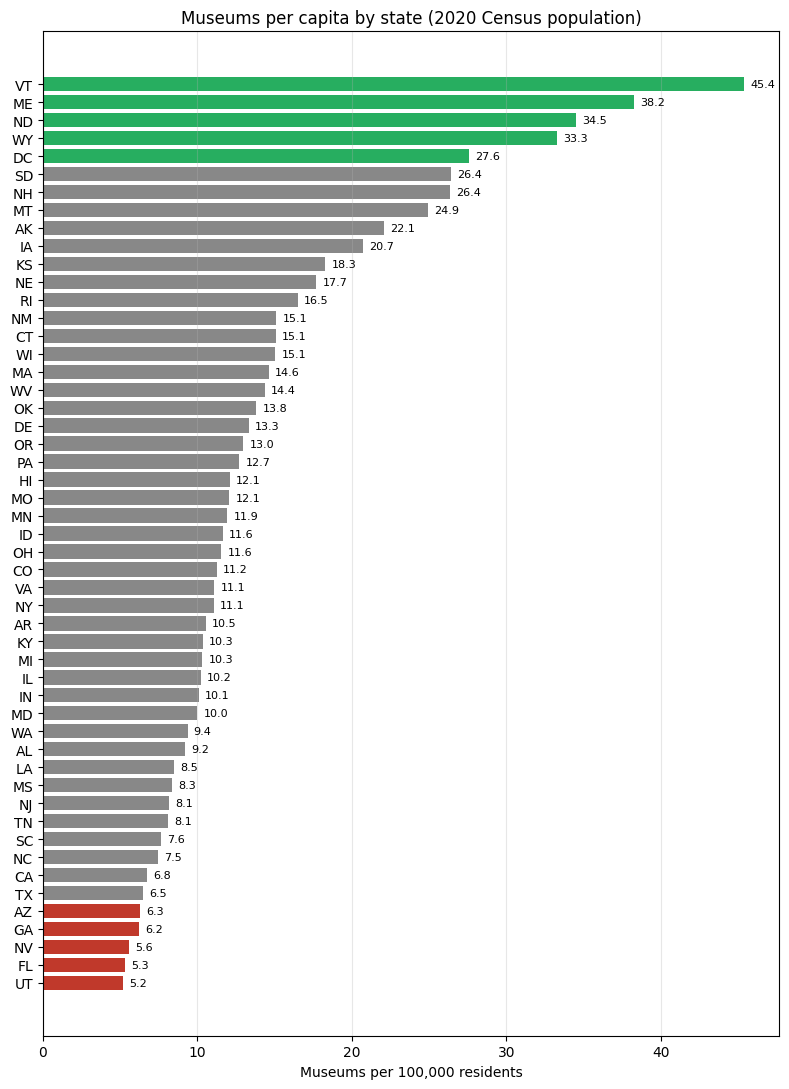

In [6]:
ranked = states.sort_values("per_100k")
colors = ["#888"] * len(ranked)
for i in range(5): colors[i] = "#c0392b"
for i in range(len(ranked) - 5, len(ranked)): colors[i] = "#27ae60"

fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(ranked.index, ranked["per_100k"], color=colors)
ax.set_xlabel("Museums per 100,000 residents")
ax.set_title("Museums per capita by state (2020 Census population)")
ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(ranked["per_100k"]):
    ax.text(v + 0.4, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### What this tells us

**Vermont leads** at 45.4 museums per 100,000 residents — about 9× the rate of Utah, which ranks last among states at 5.2. The full top of the list (Vermont, Maine, North Dakota, Wyoming, DC) is dominated by states with small populations and strong local-history traditions, where each town's historical society shows up as a separate museum.

The bottom of the list (Utah, Florida, Nevada, Georgia, Arizona) is mostly Sunbelt states with rapid population growth that hasn't been matched by a proportional growth in museums. Florida has 1,149 museums in absolute terms — the seventh-highest in the country — but its 21.5 million residents pull the per-capita ratio down.

**The takeaway:** "most museums" and "most museums per capita" are nearly opposite rankings. Population is by far the strongest predictor of raw museum count, and per-capita analysis is the only way to surface real differences in museum density.

---
## Question 4: How many zoos and aquariums are in the dataset?

This is more complicated than it sounds. The IMLS bundles zoos, aquariums, and wildlife conservation into a single combined category called `Zoo, Aquarium, Or Wildlife Conservation` — there's no separate tag distinguishing them. To count zoos and aquariums separately, we need to combine the category filter with name pattern matching.

In [7]:
category_mask = df["museum_type"] == "Zoo, Aquarium, Or Wildlife Conservation"
category_subset = df[category_mask]

# Names containing 'zoo' (with word boundary to exclude 'Kalamazoo')
zoo_mask = category_subset["Museum Name"].fillna("").str.contains(
    r"\bzoo", case=False, regex=True)
aq_mask  = category_subset["Museum Name"].fillna("").str.contains(
    r"aquarium", case=False, regex=True)

zoos = category_subset[zoo_mask]
aquariums = category_subset[aq_mask]

# Aquariums split into public vs hobbyist clubs
society_mask = aquariums["Museum Name"].str.contains(r"\bsociet", case=False, regex=True)
public_aq = aquariums[~society_mask]

print(f"Total in IMLS combined category: {len(category_subset)}")
print(f"  ...zoos (name contains 'zoo')              : {len(zoos)}")
print(f"  ...aquariums (all)                          : {len(aquariums)}")
print(f"     ...public aquariums                      : {len(public_aq)}")
print(f"     ...hobbyist aquarium societies           : {len(aquariums) - len(public_aq)}")
print(f"  ...remainder (wildlife preserves, etc.)     : "
      f"{len(category_subset) - len(zoos) - len(aquariums)}")

Total in IMLS combined category: 564
  ...zoos (name contains 'zoo')              : 258
  ...aquariums (all)                          : 100
     ...public aquariums                      : 70
     ...hobbyist aquarium societies           : 30
  ...remainder (wildlife preserves, etc.)     : 206


### What this tells us

**Zoos: 258. Aquariums: 100** (or 70 if you exclude hobbyist fish-keeping societies). Together with wildlife preserves and sanctuaries, the IMLS combined category contains 564 facilities total.

Two things to know about these counts:

First, the 258 zoo count includes accredited public zoos, small private wildlife parks, and zoological societies — anything with "zoo" or "zoological" in its name. The Kalamazoo Valley Museum and similar accidental matches are excluded by the regex word boundary.

Second, 30 of the 100 aquarium-named entries are hobbyist clubs like the *Greater Detroit Aquarium Society* — local fish-keeping organizations rather than visitor-facing public aquariums. The number you'd want depends on the question: if you're studying institutional infrastructure, 100; if you're studying places visitors can go to see fish, 70.

---
## Question 5: Which organization has the highest revenue in the most recent year?

Two complications need handling. First, Tax Period is stored as YYYYMM, so we need to extract the year. Second, many museums share an EIN (Employer Identification Number) with a parent organization — Harvard's 20+ museums all file under the same 990, and the same revenue figure appears on every Harvard museum row. We need to deduplicate by EIN to get one row per filing entity.

In [8]:
df["tax_year"] = (df["Tax Period"] // 100).astype("Int64")
most_recent = int(df["tax_year"].max())

year_df = df[(df["tax_year"] == most_recent) & df["Revenue"].notna()]
unique_orgs = year_df.drop_duplicates(subset=["Employer ID Number"])

print(f"Most recent year      : {most_recent}")
print(f"Records that year     : {len(year_df):,}")
print(f"Unique organizations  : {len(unique_orgs):,}")

winner = unique_orgs.loc[unique_orgs["Revenue"].idxmax()]
print(f"\nHighest-revenue organization in {most_recent}:")
print(f"  Museum Name : {winner['Museum Name']}")
print(f"  Legal Name  : {winner['Legal Name']}")
print(f"  Location    : {winner['city']}, {winner['state']}")
print(f"  Type        : {winner['museum_type']}")
print(f"  Revenue     : ${winner['Revenue']:,.0f}")

Most recent year      : 2015
Records that year     : 8
Unique organizations  : 7

Highest-revenue organization in 2015:
  Museum Name : PORTUGUESE AMERICAN WAR VETERANS POST 1
  Legal Name  : PORTUGUESE AMERICAN WAR VETERANS POST 1
  Location    : Peabody, MA
  Type        : Historic Preservation
  Revenue     : $226,856


### What this tells us

Strictly answering the question, the highest-revenue organization filing in 2015 was the **Portuguese American War Veterans Post 1** in Peabody, Massachusetts, classified as Historic Preservation, with $226,856 in revenue.

But this answer is misleading. 2015 only contains 127 records — these are organizations with unusual fiscal years or late filings. The bulk of recent data lives in 2014, where the top filer is the University of Miami (filing on behalf of the Gifford Arboretum) at $3 billion — the entire university's institutional revenue, not the arboretum's.

**The deeper problem** is one we'll see throughout this analysis. The IMLS dataset's Revenue field reflects the Form 990 filing of whatever legal entity owns the museum. For museums owned by universities (and many of the largest museums are), the revenue field contains the entire university's revenue. This dataset cannot tell you the revenue of, say, the Harvard Art Museums separately — only the revenue of "President and Fellows of Harvard College." If you need standalone-museum revenue, this isn't the right source.

---
## Question 6: How do museum types differ across the country?

Two-thirds of US museums fall into just two categories: Historic Preservation (45%) and General Museums (26%). The remaining third — Art, History, Children's, Science, Natural History, Botanical/Nature, and Zoo/Aquarium — is where the regional differences live.

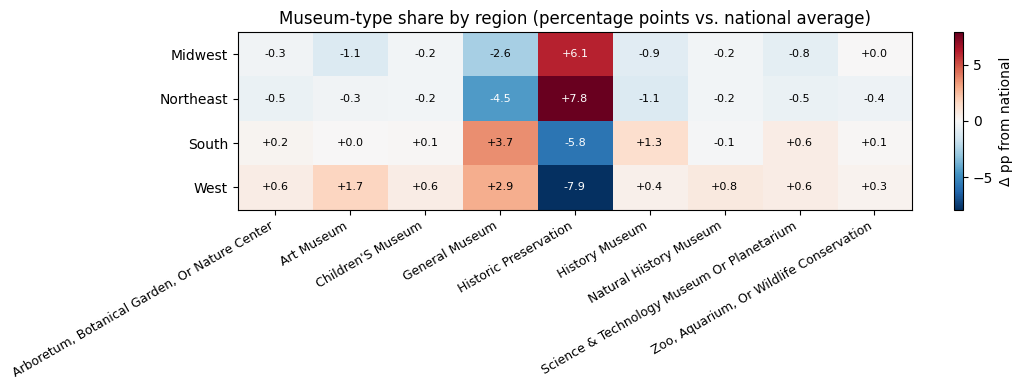

In [9]:
national = df["museum_type"].value_counts(normalize=True).mul(100).round(1)

# Aggregate to Census regions
census_region = {
    "CT":"NE","ME":"NE","MA":"NE","NH":"NE","NJ":"NE","NY":"NE","PA":"NE","RI":"NE","VT":"NE",
    "IL":"MW","IN":"MW","IA":"MW","KS":"MW","MI":"MW","MN":"MW","MO":"MW","NE":"MW","ND":"MW","OH":"MW","SD":"MW","WI":"MW",
    "AL":"S","AR":"S","DE":"S","DC":"S","FL":"S","GA":"S","KY":"S","LA":"S","MD":"S","MS":"S","NC":"S","OK":"S","SC":"S","TN":"S","TX":"S","VA":"S","WV":"S",
    "AK":"W","AZ":"W","CA":"W","CO":"W","HI":"W","ID":"W","MT":"W","NV":"W","NM":"W","OR":"W","UT":"W","WA":"W","WY":"W",
}
df["region"] = df["state"].map(census_region)

region_counts = (df.dropna(subset=["region"])
                   .groupby(["region","museum_type"]).size().unstack(fill_value=0))
region_pct = region_counts.div(region_counts.sum(axis=1), axis=0).mul(100).round(1)

diff = region_pct.sub(national, axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
lim = max(abs(diff.values.min()), abs(diff.values.max()))
im = ax.imshow(diff.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(diff.columns)))
ax.set_xticklabels(diff.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(diff.index)))
ax.set_yticklabels(["Midwest","Northeast","South","West"], fontsize=10)
ax.set_title("Museum-type share by region (percentage points vs. national average)")
for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        v = diff.iat[i, j]
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                color="white" if abs(v) > lim*0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="Δ pp from national")
plt.tight_layout()
plt.show()

### What this tells us

Each region has a distinct museum personality:

**The Northeast** is preservation-heavy. New Hampshire (66%), Vermont (62%), and Maine (62%) have museum portfolios that are nearly two-thirds historic preservation — far above the 45% national baseline. These are the country's oldest European-settled states, with dense networks of small historical societies and preserved homesteads dating back centuries.

**The West** is the most diverse region and the most distinct from the national average. It's well below national on Historic Preservation and instead distributes weight across Botanical Gardens, Natural History, Science & Technology, and Art museums. Utah is a striking individual case — above national on four separate niche categories, reflecting strong public-lands and university-museum infrastructure.

**The South** sits closer to national on most types, with elevated shares of Historic Preservation and History Museums. Texas alone has a history-museum share (10.5%) far above national (6.9%) — reflecting Texas's strong state-identity institutional tradition.

**The Midwest** tracks closest to the national average across the board — it's the "baseline America" of museum composition.

**Outliers worth noting:** DC has half its museums classified as General Museums (twice the national rate, driven by the Smithsonian system). Hawaii and Florida both more than double the national zoo/aquarium share due to climate and tourism.

---
## Question 7: Revenue and income statistics by museum type

For each museum type, compute count, mean, median, min, max, and standard deviation. With the caveat that — because of the parent-organization issue — only the median is robust to the financial-data quirks we've discussed.

In [10]:
rev_stats = (df.groupby("museum_type")["Revenue"]
               .agg(["count","mean","median","min","max","std"])
               .sort_values("median", ascending=False))
money_cols = ["mean","median","min","max","std"]
(rev_stats.style
    .format({c: "${:,.0f}" for c in money_cols})
    .format({"count": "{:,.0f}"})
    .set_caption("Revenue by museum type, sorted by median"))

,count,mean,median,min,max,std
museum_type,,,,,,
Art Museum,"1,558",119288853.135430,5689161.000000,-106157.000000,5840349457.000000,457406770.959569
Science & Technology Museum Or Planetarium,312,150946908.413462,1076971.500000,-1723674.000000,5840349457.000000,757047816.487348
"Zoo, Aquarium, Or Wildlife Conservation",215,7447496.730233,992041.000000,1668.000000,121059457.000000,15939142.488651
Natural History Museum,162,124025346.333333,637259.000000,5.000000,5840349457.000000,670918866.136343
"Arboretum, Botanical Garden, Or Nature Center",499,115804374.679359,584793.000000,-1428.000000,5840349457.000000,653429000.254147
Children'S Museum,263,1674879.007605,437097.000000,4150.000000,37020754.000000,4140334.135047
General Museum,"2,321",47568310.480396,178521.000000,-2127393.000000,5840349457.000000,413405860.647639
History Museum,"1,250",15262043.864000,126117.000000,-567630.000000,5121523000.000000,211580867.122735
Historic Preservation,"4,927",5115653.092551,81008.000000,-83151.000000,5840349457.000000,142979931.554360


In [11]:
inc_stats = (df.groupby("museum_type")["Income"]
               .agg(["count","mean","median","min","max","std"])
               .sort_values("median", ascending=False))
(inc_stats.style
    .format({c: "${:,.0f}" for c in money_cols})
    .format({"count": "{:,.0f}"})
    .set_caption("Income by museum type, sorted by median"))

,count,mean,median,min,max,std
museum_type,,,,,,
Art Museum,"1,635",375738027.727829,7510681.000000,1.000000,83181439574.000000,3758308531.794097
Science & Technology Museum Or Planetarium,321,1248099524.834891,1115335.000000,100.000000,83181439574.000000,9292070345.875931
"Zoo, Aquarium, Or Wildlife Conservation",225,8661269.568889,1004533.000000,1.000000,137491679.000000,19403258.004452
"Arboretum, Botanical Garden, Or Nature Center",535,697269810.016822,826511.000000,9.000000,83181439574.000000,6446308472.277184
Natural History Museum,172,836758488.151163,662924.500000,5.000000,83181439574.000000,6710489206.787044
Children'S Museum,268,2418091.022388,448785.500000,1.000000,104067302.000000,9699585.870901
General Museum,"2,628",291806591.460046,207100.000000,1.000000,83181439574.000000,4596182098.054888
History Museum,"1,334",26881571.676162,147327.500000,-923.000000,10650597555.000000,426724192.159435
Historic Preservation,"5,103",23287983.684499,94887.000000,1.000000,83181439574.000000,1184123344.537499


### What this tells us

**Reading the median column** (the trustworthy one):

Art Museums lead by a wide margin at $5.7M median revenue — about 5× the next category. Art museums tend to be larger institutions with significant endowments, permanent collections requiring climate-controlled facilities, and concentrated cultural philanthropy.

A mid-tier of operationally intensive institutions follows: Science & Technology (~$1.1M), Zoos and Aquariums (~$1.0M), and Natural History (~$640K). These have meaningful physical-plant requirements — planetariums, animal care, specimen storage.

Botanical Gardens (~$585K) and Children's Museums (~$437K) come next — both are typically purpose-built attractions with steady operating costs. General Museums (~$179K) and History Museums (~$126K) sit lower, with many county or regional institutions running modest budgets.

Historic Preservation is at the bottom with median revenue around $81K, despite being the single largest category by count. This category is dominated by tiny historical societies and small preserved sites operating on volunteer labor and modest annual fundraising.

**The order tells a story:** revenue tracks roughly with operational complexity and visitor-attraction status. Art and science museums draw philanthropy and admissions; historic houses and small society museums draw neither at scale.

**Why means and standard deviations are unreliable:** Compare Art Museums (median $5.7M, mean $119M) — the mean is over 20× the median. This is the parent-organization effect: Harvard's $5.8B revenue attaches to every Harvard museum row across multiple categories. Means and maxes are dragged upward, and standard deviations balloon to hundreds of millions. Treat the median column as the only reliable comparison.

---
## Question 8: Revenue distribution across the dataset

A histogram of museum revenue tells us the *shape* of museum financials — what "typical" looks like, and how far the tail extends.

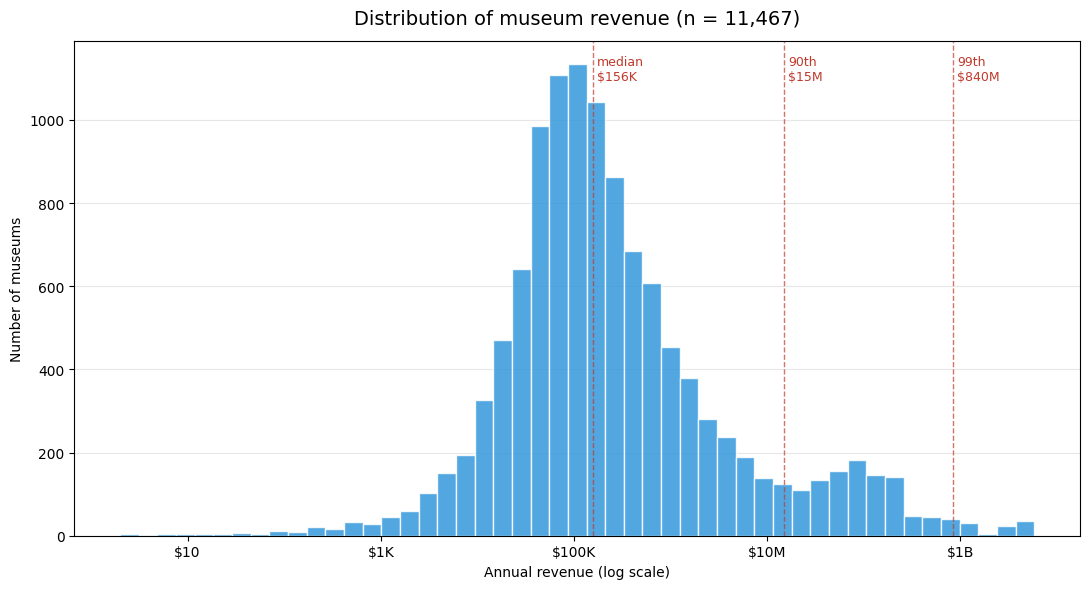

In [12]:
rev_pos = df["Revenue"].dropna()
rev_pos = rev_pos[rev_pos > 0]

fig, ax = plt.subplots(figsize=(11, 6))
bins = np.logspace(np.log10(rev_pos.min()), np.log10(rev_pos.max()), 50)
ax.hist(rev_pos, bins=bins, color="#3498db", edgecolor="white", alpha=0.85)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(money_fmt)
ax.set_xlabel("Annual revenue (log scale)")
ax.set_ylabel("Number of museums")
ax.set_title(f"Distribution of museum revenue (n = {len(rev_pos):,})", fontsize=14, pad=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for p, label in [(50,"median"),(90,"90th"),(99,"99th")]:
    v = np.percentile(rev_pos, p)
    ax.axvline(v, color="#c0392b", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(v*1.1, ax.get_ylim()[1]*0.92, f"{label}\n{money(v)}",
            fontsize=9, color="#c0392b")
plt.tight_layout()
plt.show()

### What this tells us

Museum revenue follows an approximately log-normal distribution — a bell curve in log space, spanning nine orders of magnitude from $1 to $6 billion. The chart is on a log scale because a linear scale would compress 99% of the data into the leftmost bar.

**The headline numbers:** half of all museums report less than $156K in annual revenue. The top 10% are above $15M, and the top 1% exceed $840M.

**The secondary hump on the right** (the cluster of bars between $1B and $10B) isn't a feature of museum finance per se. It's the trailing edge created by Form 990 filings from large universities — Harvard, Stanford, Yale, NYU, Johns Hopkins, and dozens of others all appear here at full institutional scale because their museums share their EIN. This is the same parent-organization issue we've flagged in earlier sections, made visible as a bump in the distribution.

**The practical takeaway:** there's no single "typical" museum revenue. There's a typical *small* museum (~$50K), a typical *mid-sized* museum (~$500K), and a typical *large* museum (~$10M). What's typical depends entirely on which order of magnitude you're interested in.

---
## Conclusions and key takeaways

**On geographic distribution:** US museums are highly concentrated in the most populous states — California, New York, and Texas alone account for ~20% of the total. But per-capita analysis flips the picture entirely: small New England and Mountain West states with strong local-history traditions (Vermont, Maine, North Dakota, Wyoming) lead the rankings, while fast-growing Sunbelt states (Utah, Nevada, Florida) sit at the bottom.

**On museum types:** Historic Preservation and General Museums together account for 71% of the country's museums. The remaining 29% — Art, Science, Children's, Natural History, Botanical, Zoo/Aquarium, History — is where regional character emerges. The Northeast is preservation-heavy, the West is diversified into nature and science, the South leans into history, and the Midwest hews closest to the national average.

**On museum finances:** Art museums are by far the best-funded type (median revenue $5.7M), followed by science museums and zoos. Historic preservation sites — the largest category by count — are the least-funded (median $81K), reflecting their typical operating model of small staff and volunteer labor. Revenue is distributed log-normally over nine orders of magnitude, with no single "typical" value.

**On data limitations:** the parent-organization issue affects nearly every analysis involving revenue or income. University-owned museums inherit their parent's full Form 990 revenue, so the top of every type's revenue ranking is dominated by university financials, not museum financials. Means and standard deviations are inflated; medians are robust. If the goal is standalone-museum revenue, this dataset would need to be cross-referenced with individual museum 990s — a significantly larger project.

**On data completeness:** about a third of museums have usable revenue figures; the rest either don't file 990s or file the postcard version that omits dollar amounts. Any financial conclusion in this report represents that filing third — biased toward larger institutions — not the dataset as a whole.